In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [32]:
visualize_df = pd.read_csv("BTM_comp_Data visualize_1.csv")
visualize_df

,,,,,,,,,,,,,,,"New International Student Enrollment, 2008/09 - 2024/25"
NaN,2010/11,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24,2024/25
Undergraduate,"84,543","90,903","102,069","109,486","112,765","119,262","115,841","108,539","106,881","104,907","69,183","90,642","95,681","93,978","98,963"
Graduate,"89,505","92,211","100,129","108,519","121,637","126,516","124,888","117,960","119,828","120,332","66,082","146,526","168,920","176,084","150,536"
Non-Degree,"40,442","45,353","48,722","52,123","59,364","54,965","50,107","45,239","42,674","42,473","10,263","24,793","33,922","28,643","27,619"
Total,"214,490","228,467","250,920","270,128","293,766","300,743","290,836","271,738","269,383","267,712","145,528","261,961","298,523","298,705","277,118"


C:\Users\hp\AppData\Local\Temp\ipykernel_19364\4278050955.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x.replace(',', '')))


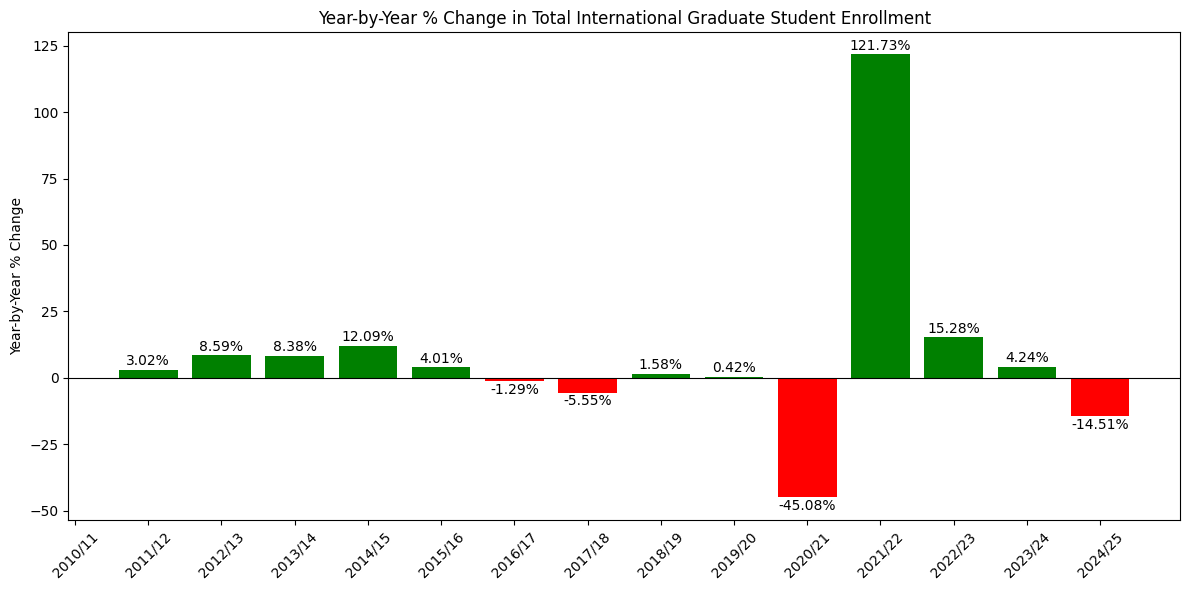

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Data starting from 2010/11
data = {
    "Category": ["Undergraduate", "Graduate", "Non-Degree", "Total"],
    "2010/11": ["84,543","89,505","40,442","214,490"],
    "2011/12": ["90,903","92,211","45,353","228,467"],
    "2012/13": ["102,069","100,129","48,722","250,920"],
    "2013/14": ["109,486","108,519","52,123","270,128"],
    "2014/15": ["112,765","121,637","59,364","293,766"],
    "2015/16": ["119,262","126,516","54,965","300,743"],
    "2016/17": ["115,841","124,888","50,107","290,836"],
    "2017/18": ["108,539","117,960","45,239","271,738"],
    "2018/19": ["106,881","119,828","42,674","269,383"],
    "2019/20": ["104,907","120,332","42,473","267,712"],
    "2020/21": ["69,183","66,082","10,263","145,528"],
    "2021/22": ["90,642","146,526","24,793","261,961"],
    "2022/23": ["95,681","168,920","33,922","298,523"],
    "2023/24": ["93,978","176,084","28,643","298,705"],
    "2024/25": ["98,963","150,536","27,619","277,118"]
}

# Create DataFrame
df = pd.DataFrame(data)
df.set_index("Category", inplace=True)
df = df.applymap(lambda x: int(x.replace(',', '')))
df_pct_change = df.pct_change(axis=1) * 100
df_pct_change = df_pct_change.round(2)

# Plot for Undergraduate
df_plot = df_pct_change.T
category = "Graduate"

colors = ['green' if x >= 0 else 'red' for x in df_plot[category]]

plt.figure(figsize=(12, 6))
bars = plt.bar(df_plot.index, df_plot[category], color=colors)
plt.axhline(0, color='black', linewidth=0.8)  # horizontal line at 0

# Add percentage labels closer to the bar
offset = 0.5  # smaller offset for negative bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (offset if height >= 0 else -offset),  # closer to the bar
        f"{height:.2f}%",
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=10
    )

plt.xticks(rotation=45)
plt.ylabel('Year-by-Year % Change')
plt.title(f'Year-by-Year % Change in Total International Graduate Student Enrollment')
plt.tight_layout()
plt.show()

